In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:

#DATA LOADING

import kagglehub
import os
import tensorflow as tf
from tensorflow.keras import layers

# Download dataset
path = kagglehub.dataset_download("subhajournal/busi-breast-ultrasound-images-dataset")

print("Dataset downloaded at:", path)
print("Folders:", os.listdir(path))

# Fix directory (important)
data_dir = os.path.join(path, "Dataset_BUSI_with_GT")

print("Using data directory:", data_dir)
print("Classes:", os.listdir(data_dir))

# Parameters
IMG_SIZE = 128
BATCH_SIZE = 32

# Load dataset (auto split)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Class Names:", class_names)

# Normalize
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

100%|██████████| 195M/195M [00:05<00:00, 34.1MB/s]

Extracting files...


Dataset downloaded at: /root/.cache/kagglehub/datasets/subhajournal/busi-breast-ultrasound-images-dataset/versions/1
Folders: ['Dataset_BUSI_with_GT']
Using data directory: /root/.cache/kagglehub/datasets/subhajournal/busi-breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT
Classes: ['normal', 'malignant', 'benign']
Found 1578 files belonging to 3 classes.
Using 1263 files for training.
Found 1578 files belonging to 3 classes.
Using 315 files for validation.
Class Names: ['benign', 'malignant', 'normal']


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras import models, layers

In [5]:
def build_standard_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    return model

model_std = build_standard_cnn()

model_std.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_std.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_std = model_std.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5463 - loss: 0.8935 - val_accuracy: 0.6921 - val_loss: 0.7877
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7039 - loss: 0.6756 - val_accuracy: 0.7206 - val_loss: 0.6823
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7363 - loss: 0.5706 - val_accuracy: 0.7302 - val_loss: 0.6598
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7799 - loss: 0.5036 - val_accuracy: 0.7333 - val_loss: 0.6449
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8353 - loss: 0.3816 - val_accuracy: 0.7524 - val_loss: 0.7316
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8757 - loss: 0.3116 - val_accuracy: 0.7778 - val_loss: 0.7595
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9129 - loss: 0.2275 - val_accuracy: 0.8063 - val_loss: 0.8083
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9351 - loss: 0.1961 - val_accuracy: 0.7683 - val_loss:

In [7]:
def build_dsc_cnn():
    model = models.Sequential([
        layers.Input(shape=(128,128,3)),

        layers.SeparableConv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.SeparableConv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.SeparableConv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    return model

model_dsc = build_dsc_cnn()

model_dsc.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_dsc.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 126, 126, 32)   │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 61, 61, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 28, 28, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,223,230 (12.30 MB)

 Trainable params: 3,223,230 (12.30 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_dsc = model_dsc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5653 - loss: 0.9608 - val_accuracy: 0.6032 - val_loss: 0.8947
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 796ms/step - accuracy: 0.5938 - loss: 0.8333 - val_accuracy: 0.5905 - val_loss: 0.7642
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 766ms/step - accuracy: 0.6564 - loss: 0.6969 - val_accuracy: 0.6889 - val_loss: 0.7119
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 805ms/step - accuracy: 0.7284 - loss: 0.6077 - val_accuracy: 0.7238 - val_loss: 0.5972
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 772ms/step - accuracy: 0.7799 - loss: 0.5064 - val_accuracy: 0.7556 - val_loss: 0.5635
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 770ms/step - accuracy: 0.8139 - loss: 0.4532 - val_accuracy: 0.7746 - val_loss: 0.6295
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 870ms/step - accuracy: 0.8353 - loss: 0.4356 - val_accuracy: 0.7968 - val_loss: 0.5216
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 770ms/step - accuracy: 0.8630 - loss: 0.3421 - val_accurac

In [9]:
print("Standard CNN Params:", model_std.count_params())
print("Depthwise CNN Params:", model_dsc.count_params())

Standard CNN Params: 3305027
Depthwise CNN Params: 3223230


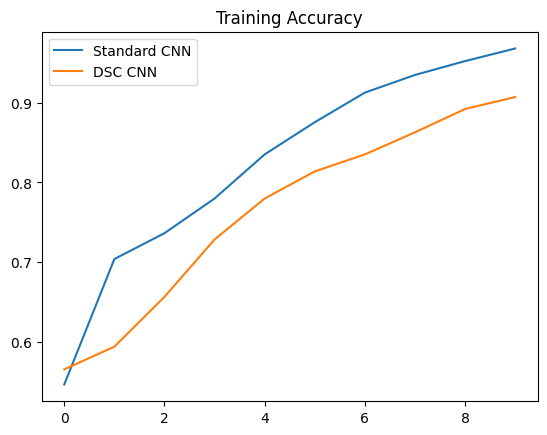

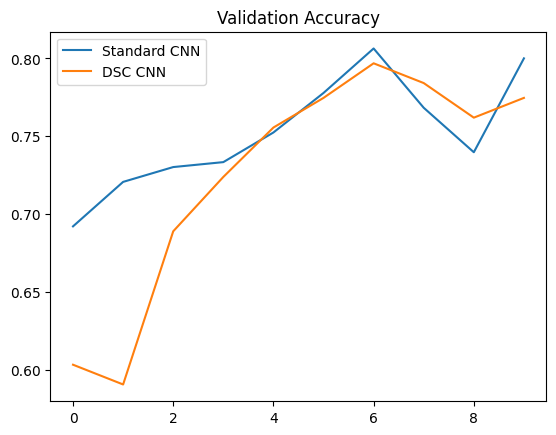

In [10]:
plt.figure()
plt.plot(history_std.history['accuracy'], label='Standard CNN')
plt.plot(history_dsc.history['accuracy'], label='DSC CNN')
plt.legend()
plt.title("Training Accuracy")
plt.show()

plt.figure()
plt.plot(history_std.history['val_accuracy'], label='Standard CNN')
plt.plot(history_dsc.history['val_accuracy'], label='DSC CNN')
plt.legend()
plt.title("Validation Accuracy")
plt.show()

In [11]:
def evaluate_model(model, name):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(f"\n{name} Report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [18]:
import time
def measure_inference_time(model, dataset, name):
    start = time.time()

    for images, _ in dataset.take(10):  # test on 10 batches
        _ = model.predict(images)

    end = time.time()

    total_time = end - start
    print(f"{name} Inference Time (10 batches): {total_time:.2f} sec")
    return total_time

print("\n Speed Comparison:\n")

time_std = measure_inference_time(model_std, val_ds, "Standard CNN")
time_dsc = measure_inference_time(model_dsc, val_ds, "DSC CNN")

improvement = ((time_std - time_dsc) / time_std) * 100
print(f"\nSpeed Improvement: {improvement:.2f}%")


 Speed Comparison:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Standard CNN Inference Time (10 batches): 6.58 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
DSC CNN Inference Time (10 batches): 4.07 sec

Speed Improvement: 38.16%


In [19]:
# =========================
# 📊 COMPUTATION COMPARISON
# =========================

def compute_standard_conv(H, W, Cin, Cout, K):
    return H * W * Cout * (K * K) * Cin

def compute_dsc_conv(H, W, Cin, Cout, K):
    depthwise = H * W * Cin * (K * K)
    pointwise = H * W * Cin * Cout
    return depthwise + pointwise

# Example from your model
layers_config = [
    (128, 128, 3, 32, 3),
    (64, 64, 32, 64, 3),
    (32, 32, 64, 128, 3)
]

std_total = 0
dsc_total = 0

print("\n Layer-wise Computation:\n")

for i, (H, W, Cin, Cout, K) in enumerate(layers_config):
    std = compute_standard_conv(H, W, Cin, Cout, K)
    dsc = compute_dsc_conv(H, W, Cin, Cout, K)

    std_total += std
    dsc_total += dsc

    print(f"Layer {i+1}:")
    print(f" Standard Conv: {std:,}")
    print(f" DSC Conv:      {dsc:,}")
    print()

print("=================================")
print(f"Total Standard CNN Computation: {std_total:,}")
print(f"Total DSC CNN Computation:      {dsc_total:,}")

reduction = ((std_total - dsc_total) / std_total) * 100
print(f"\n Computation Reduction: {reduction:.2f}%")


 Layer-wise Computation:

Layer 1:
 Standard Conv: 14,155,776
 DSC Conv:      2,015,232

Layer 2:
 Standard Conv: 75,497,472
 DSC Conv:      9,568,256

Layer 3:
 Standard Conv: 75,497,472
 DSC Conv:      8,978,432

Total Standard CNN Computation: 165,150,720
Total DSC CNN Computation:      20,561,920

 Computation Reduction: 87.55%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step

Standard CNN Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       180
           1       0.70      0.64      0.67        80
           2       0.84      0.84      0.84        55

    accuracy                           0.80       315
   macro avg       0.79      0.78      0.78       315
weighted avg       0.80      0.80      0.80       315



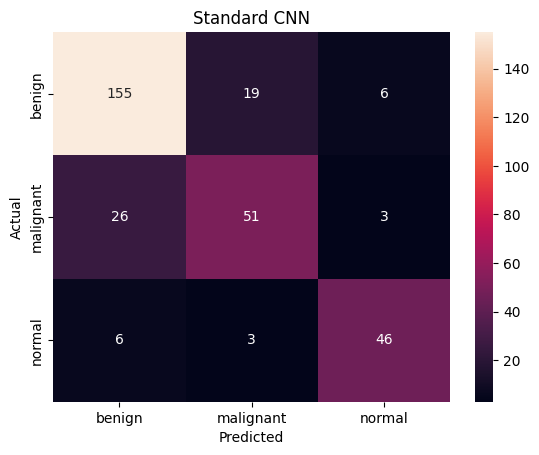

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step

Depthwise CNN Report:

              precision    recall  f1-score   support

           0       0.86      0.77      0.81       180
           1       0.58      0.80      0.67        80
           2       0.95      0.76      0.85        55

    accuracy                           0.77       315
   macro avg       0.80      0.78      0.78       315
weighted avg       0.80      0.77      0.78       315



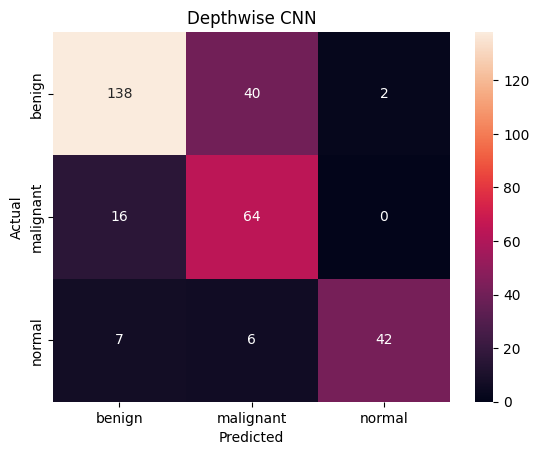

In [12]:
evaluate_model(model_std, "Standard CNN")
evaluate_model(model_dsc, "Depthwise CNN")


🔍 Testing Multiple Images...


Testing benign image:
Path: /root/.cache/kagglehub/datasets/subhajournal/busi-breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT/benign/benign (69).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


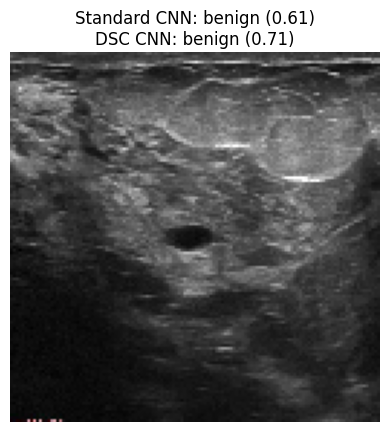


Testing malignant image:
Path: /root/.cache/kagglehub/datasets/subhajournal/busi-breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT/malignant/malignant (34).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


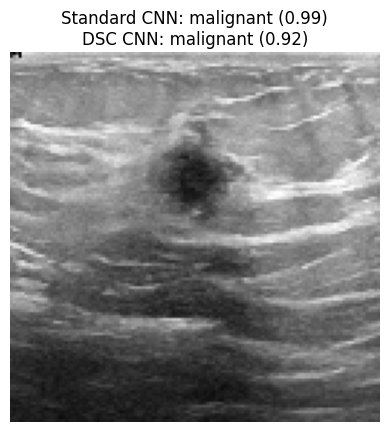


Testing normal image:
Path: /root/.cache/kagglehub/datasets/subhajournal/busi-breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT/normal/normal (8).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


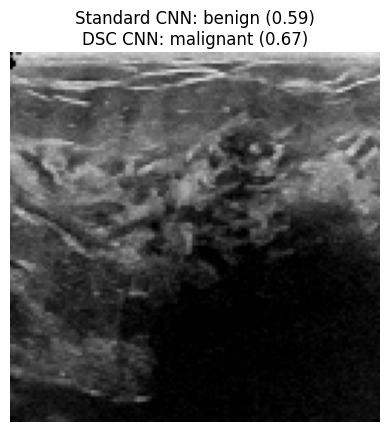

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.preprocessing import image

IMG_SIZE = 128

def predict_image(img_path):

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_std = model_std.predict(img_array)
    pred_dsc = model_dsc.predict(img_array)

    std_class = class_names[np.argmax(pred_std)]
    dsc_class = class_names[np.argmax(pred_dsc)]

    std_conf = np.max(pred_std)
    dsc_conf = np.max(pred_dsc)

    plt.figure()
    plt.imshow(img)
    plt.axis('off')

    plt.title(
        f"Standard CNN: {std_class} ({std_conf:.2f})\n"
        f"DSC CNN: {dsc_class} ({dsc_conf:.2f})"
    )

    plt.show(block=True)
    plt.pause(0.1)

print("\n🔍 Testing Multiple Images...\n")

for cls in ["benign", "malignant", "normal"]:

    folder = os.path.join(data_dir, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])

    print(f"\nTesting {cls} image:")
    print("Path:", img_path)

    predict_image(img_path)

## Final Conclusion

This project compared Standard CNN and Depthwise Separable CNN (DSC) for breast ultrasound classification.

The results show that:

- DSC reduces computational cost by **87.55%**, making it highly efficient - Efficiency (low computation)
- DSC improves inference speed by **38.16%**- Speed (faster inference)
- Accuracy drops slightly (80% → 77%), but remains comparable

### Final Insight

Standard CNN provides slightly better overall accuracy due to higher model complexity.  

Depthwise Separable Convolution first applies depthwise filtering per channel, capturing fine spatial details like irregular edges and textures of malignant tumors.
Then, a pointwise (1×1) convolution combines these channels, preserving important features without early mixing.